In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

Chuẩn bị và xử lý dữ liệu

In [3]:
def create_dataset(dataset, time_step=10):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        dataX.append(dataset[i:i+time_step])
        dataY.append(dataset[i+time_step])
    return np.array(dataX), np.array(dataY)

# Load data
file_paths = {
    "Brent_Crude_Oil": r"D:\PTDLKinhDoanh\Dataset\Brent_Crude_Oil_data.csv",
    "Crude_Oil": r"D:\PTDLKinhDoanh\Dataset\Crude_Oil_data.csv",
    "Heating_Oil": r"D:\PTDLKinhDoanh\Dataset\Heating_Oil_data.csv",
    "Natural_Gas": r"D:\PTDLKinhDoanh\Dataset\Natural_Gas_data.csv",
    "RBOB_Gasoline": r"D:\PTDLKinhDoanh\Dataset\RBOB_Gasoline_data.csv"
}

# Đọc dữ liệu vào dictionary
df = {name: pd.read_csv(path) for name, path in file_paths.items()}

# Kiểm tra dữ liệu
df["Brent_Crude_Oil"].head()

,date,open,high,low,close,volume
0,2007-07-30,75.849998,76.529999,75.440002,75.739998,2575
1,2007-07-31,75.699997,77.169998,75.669998,77.050003,3513
2,2007-08-01,77.000000,77.059998,74.860001,75.349998,3930
3,2007-08-02,75.220001,76.209999,74.269997,75.760002,6180
4,2007-08-03,75.389999,76.000000,74.529999,74.750000,4387


Tiền xử lý và chuẩn hóa dữ liệu

In [4]:
# Chuẩn hóa giá đóng cửa
def preprocess_data(data):
    close_prices = data[['close']]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_close = scaler.fit_transform(close_prices)
    return pd.Series(scaled_close.flatten()), scaler

# Xử lý dữ liệu cho tất cả các tập
processed_data = {}
scalers = {}
for name, data in df.items():
    processed_data[name], scalers[name] = preprocess_data(data)

Chia dữ liệu thành Train/Validation/Test

In [5]:
def split_data(series, train_size=0.7, val_size=0.2):
    total_len = len(series)
    train_len = int(total_len * train_size)
    val_len = int(total_len * val_size)
    test_len = total_len - train_len - val_len
    
    train_data = series[:train_len]
    val_data = series[train_len:train_len+val_len]
    test_data = series[train_len+val_len:]
    
    return train_data, val_data, test_data

# Chia dữ liệu cho tất cả các tập
train_data, val_data, test_data = {}, {}, {}
for name, data in processed_data.items():
    train_data[name], val_data[name], test_data[name] = split_data(data)

 Xây dựng và huấn luyện mô hình

In [6]:
def build_and_train_model(X_train, y_train, X_val, y_val, model_type="RNN"):
    model = Sequential()
    if model_type == "RNN":
        model.add(SimpleRNN(50, input_shape=(X_train.shape[1], 1)))
    elif model_type == "LSTM":
        model.add(LSTM(50, input_shape=(X_train.shape[1], 1)))
    elif model_type == "GRU":
        model.add(GRU(50, input_shape=(X_train.shape[1], 1)))
    
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=100, batch_size=16, verbose=0)
    
    return model, history

# Áp dụng cho từng loại dữ liệu
models = {}
for name in df:
    X_train, y_train = create_dataset(train_data[name].to_numpy())
    X_val, y_val = create_dataset(val_data[name].to_numpy())
    X_test, y_test = create_dataset(test_data[name].to_numpy())
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    model_rnn, _ = build_and_train_model(X_train, y_train, X_val, y_val, model_type="RNN")
    model_lstm, _ = build_and_train_model(X_train, y_train, X_val, y_val, model_type="LSTM")
    model_gru, _ = build_and_train_model(X_train, y_train, X_val, y_val, model_type="GRU")
    
    models[name] = {"RNN": model_rnn, "LSTM": model_lstm, "GRU": model_gru}

d:\Python_3_10\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Đánh giá và vẽ kết quả

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


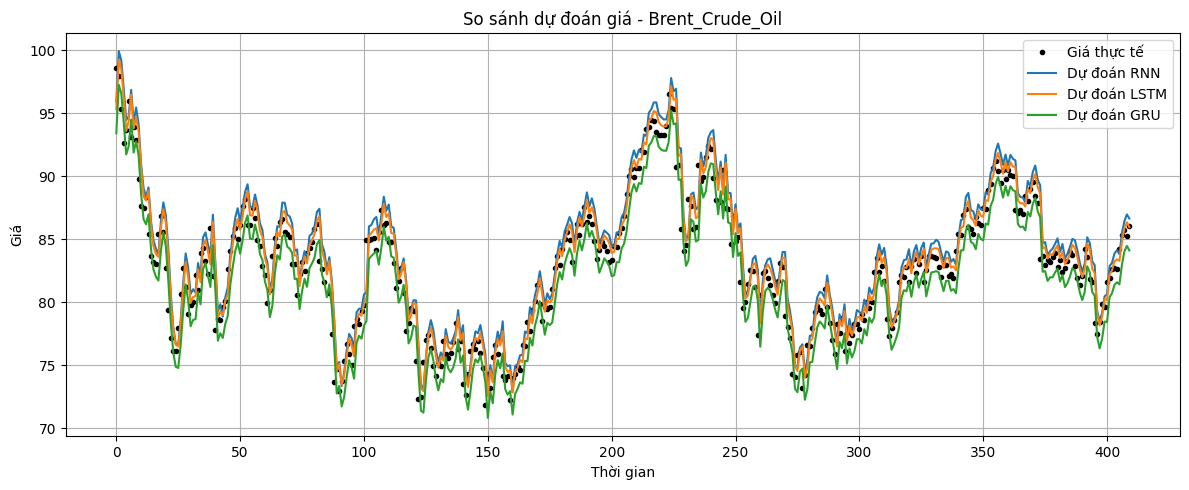

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


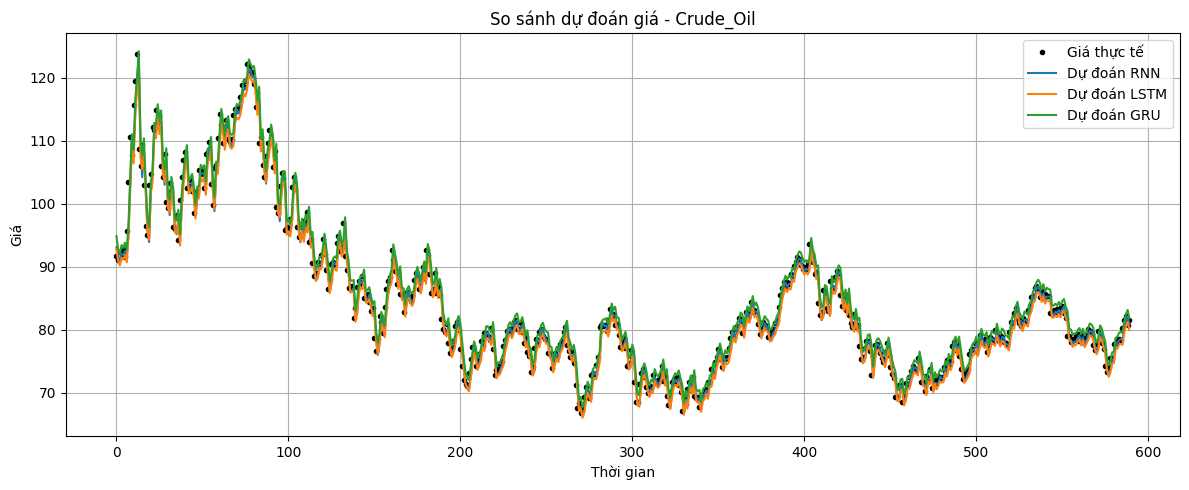

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


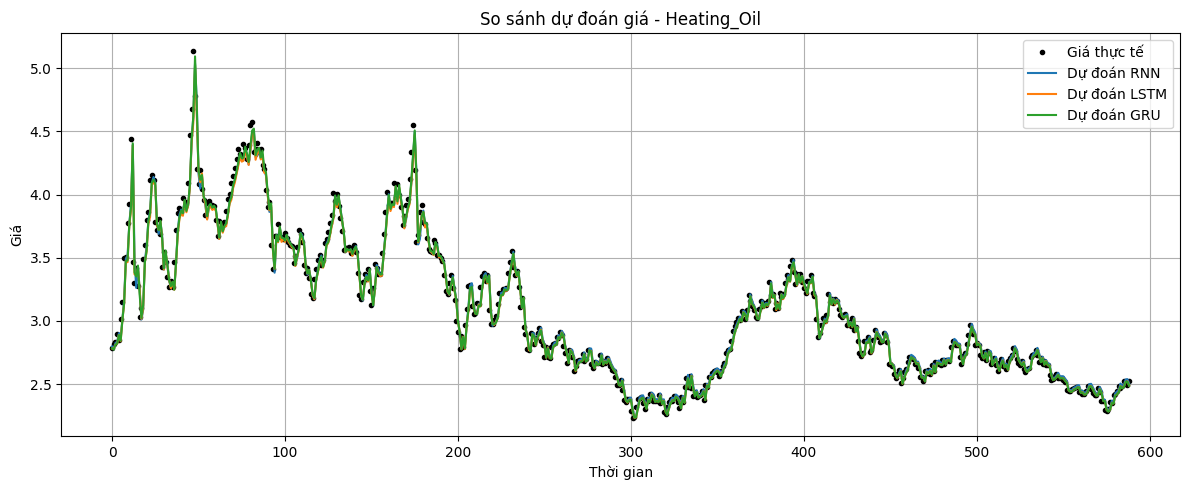

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


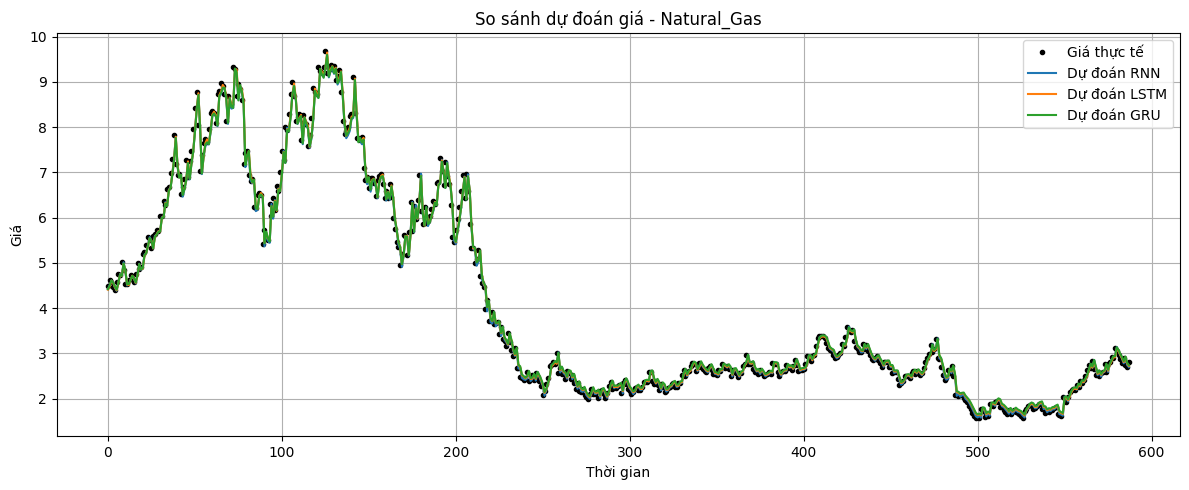

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


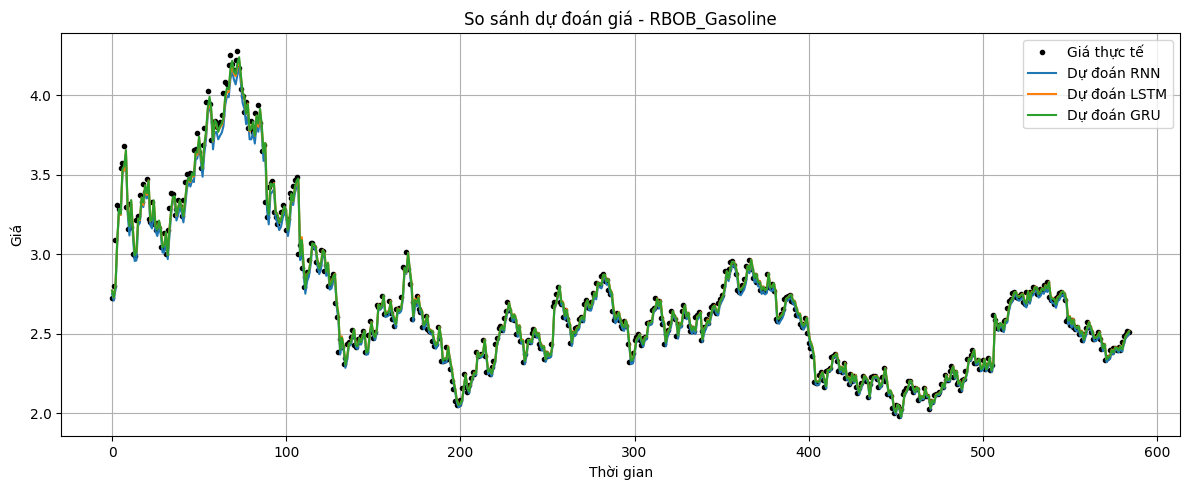

In [7]:
def evaluate_models(models, X_test, y_test, scaler, name):
    predictions = {}
    rmses = {}
    
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        y_pred_inv = scaler.inverse_transform(y_pred)
        y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
        
        rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
        predictions[model_name] = y_pred_inv
        rmses[model_name] = rmse
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_inv, 'o', label='Giá thực tế', color='black', markersize=3)
    for model_name, pred in predictions.items():
        plt.plot(pred, label=f'Dự đoán {model_name}')
    
    plt.title(f"So sánh dự đoán giá - {name}")
    plt.xlabel("Thời gian")
    plt.ylabel("Giá")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Đánh giá cho tất cả các mô hình
for name in models:
    X_test, y_test = create_dataset(test_data[name].to_numpy())
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    evaluate_models(models[name], X_test, y_test, scalers[name], name)